# TA7 - Trackstars

Rubric 
- A python package for feature engineering is demonstrated
- A small dataset for testing purposes is either a built-in dataset, accessible via a python package, or added to the data/ repository
- Code is a script, not a notebook
- Code is clean and well organized
- Code is documented with docstrings and comments 
- Code is free of commented out code (ie debug print statements)
- Script has a clear name
- Branching and PRs were done appropriately
- Requirements are included in the text of the PR and are correct and versioned
- The code runs as documented

❗️ Any demo code will need to be migrated to a streamlit app or similar for the assignment. 

In [1]:
# The instinct here is to engineer general and dataset-specific features 
# that might improve our ability to do classification with this dataset

In [2]:
# See overview of pytorch dataset interactions here: 
# https://pytorch.org/tutorials/beginner/basics/data_tutorial.html

import torch 
from torch.utils.data import Dataset
from torchvision.datasets import FGVCAircraft

import cv2

In [3]:
import matplotlib.pyplot as plt 

In [106]:
# See overview of built-in FGVCAircraft interface here: 
# https://pytorch.org/vision/main/generated/torchvision.datasets.FGVCAircraft.html#torchvision.datasets.FGVCAircraft
#
# ... and the implementation here: 
# https://pytorch.org/vision/0.12/_modules/torchvision/datasets/fgvc_aircraft.html
#
# annotation_level is one of 'variant', 'family' or 'manufacturer', in descending order of 
# granularity

training_data = FGVCAircraft(
    root = 'data',
    annotation_level = 'family', 
    download = True
) 

In [5]:
len(training_data) 

6667

In [6]:
# Dataset has an image and an int, these can be retrieved by indexing the 
# object or passing an index to __getitem__ ... 

In [7]:
training_data[0]

(<PIL.Image.Image image mode=RGB size=1024x695>, 12)

In [8]:
display(training_data.__getitem__(0))

(<PIL.Image.Image image mode=RGB size=1024x695>, 12)

In [157]:
sample = training_data[556]

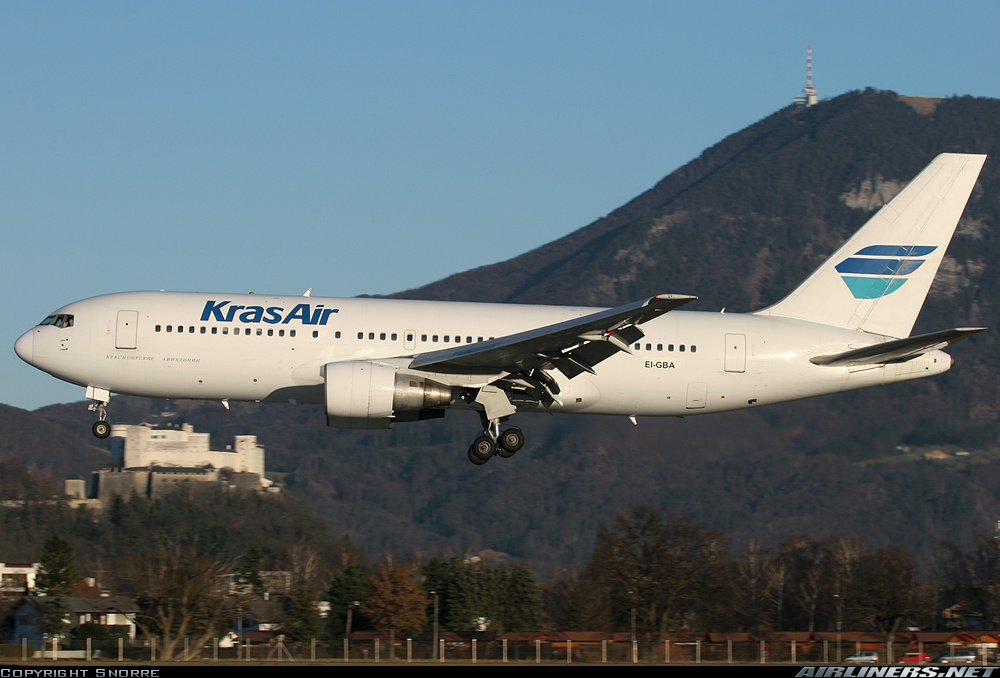

In [158]:
# Image in the first part of the tuple... 
sample[0]

In [159]:
# 'Target' appears to be encoded in the int, we specified 'class' above so 
# presume this is the class of this image
sample[1]

18

In [160]:
training_data.classes[sample[1]]

'Boeing 767'

In [161]:
# Peeking at the implementation gives us insight into the labels parsed 
# from the on-disk dataset... class_to_idx will always map to whatever 
# level of category we specified in the constructor (here 'family'). E.g. 
# we can't now retrieve manufacturer of the sample without creating a new 
# instance or digging around in the dataset files

for i, c in enumerate(training_data.class_to_idx): 
    if i == sample[1]: 
        print(c) 

Boeing 767


In [162]:
def render_sample(index): 
    sample = training_data[index] 

    category = training_data.classes[sample[1]]
        
    print(f"Category of sample #{index} is {category}")
    display(sample[0])

Category of sample #423 is Boeing 747


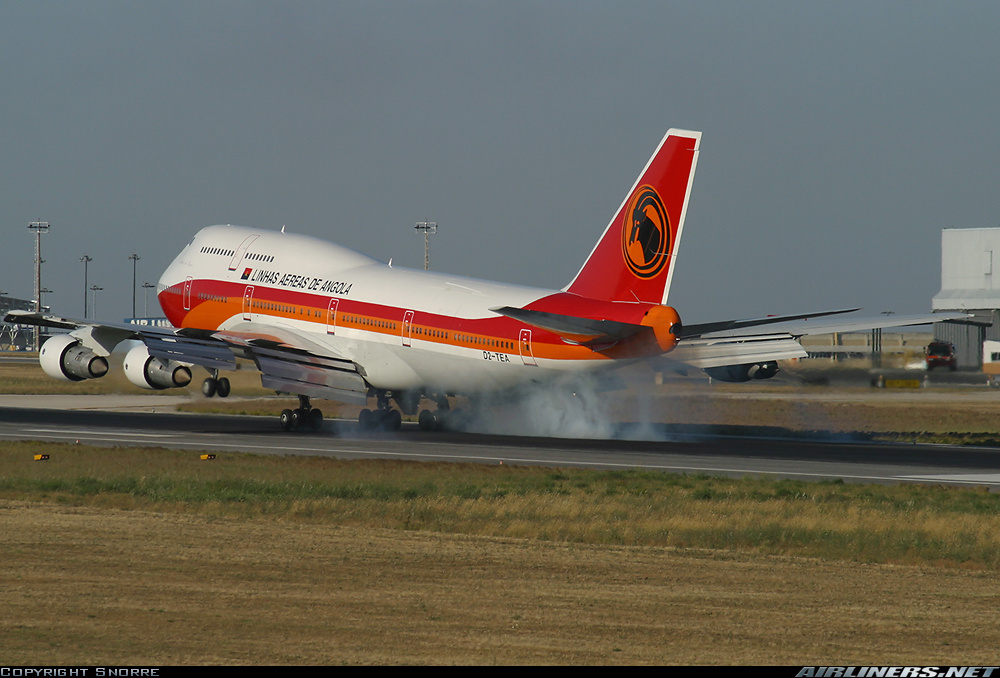

In [164]:
render_sample(423)

# Corner Detection

In [169]:
import PIL
import numpy as np

In [307]:
# Convert PIL format to CV2-compatible nparry-based image and shift to
# grayscale (required for corner detection algorithm)
img = np.array(sample[0]) 
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

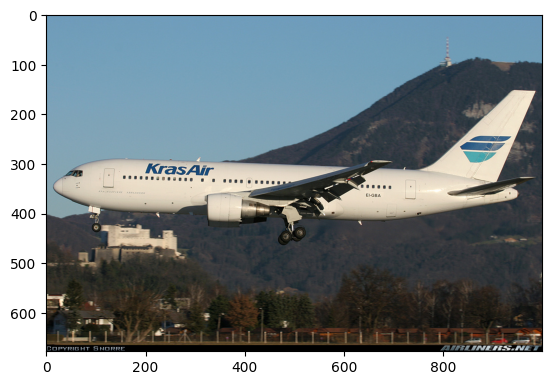

In [308]:
plt.imshow(img)

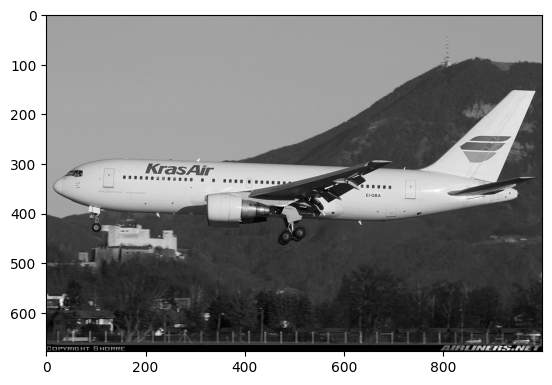

In [309]:
plt.imshow(gray, cmap='gray')

In [310]:
# Examples courtesy of https://docs.opencv.org/4.x/dc/d0d/tutorial_py_features_harris.html
corners = cv2.cornerHarris(
    gray,        # Grayscale float32 image
    blockSize=6, # Neighborhood considered for a corner
    ksize=11,     # Aperture of the Sobel derivative
    k=0.5        # Harris detector free parameter (??) 
) 

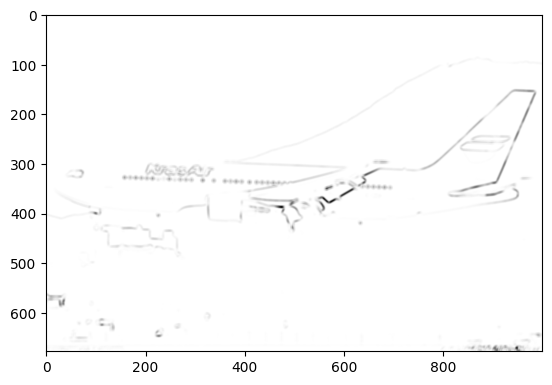

In [311]:
plt.imshow(corners, cmap='gray') 

In [316]:
thresh_img = img.copy()
thresh_img[corners > corners.mean()] = [255,0,255]

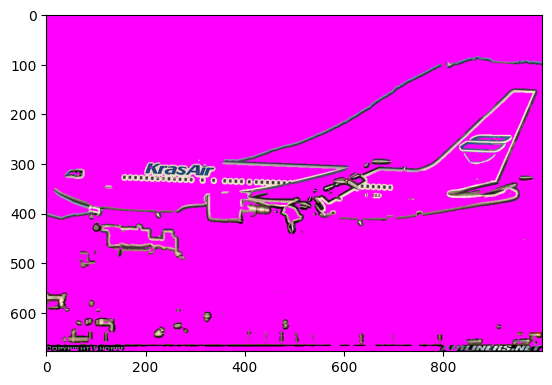

In [317]:
plt.imshow(thresh_img) 

## Depth Field 

In [318]:
smooth_img = cv2.blur(img, (3,3))

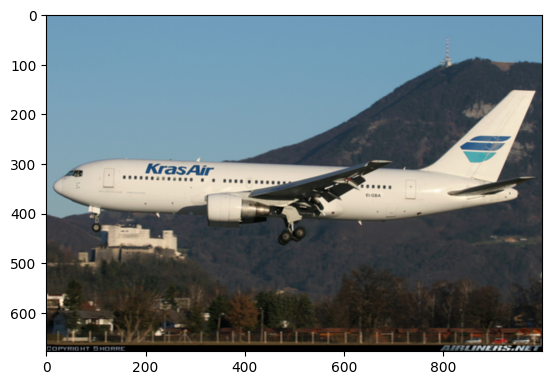

In [319]:
plt.imshow(smooth_img) 

## Superpixel segmentation

In [320]:
import cv2

# We use the concept of a superpixel to establish large picture elements based 
# on the LSC segmentation algorithm. See openCV superpixel docs and the LSC class: 
# https://docs.opencv.org/3.4/df/d6c/group__ximgproc__superpixel.html
# https://docs.opencv.org/4.x/d5/da0/classcv_1_1ximgproc_1_1SuperpixelLSC.html

In [321]:
lsc = cv2.ximgproc.createSuperpixelLSC(
    smooth_img,            # target image 
    region_size=20, # average superpixel, in pixels
    ratio=0.075       # superpixel compactness
)     

In [322]:
lsc.iterate(5)

In [323]:
lsc.getNumberOfSuperpixels()

1650

In [324]:
mask = lsc.getLabelContourMask(img, thick_line=False) 

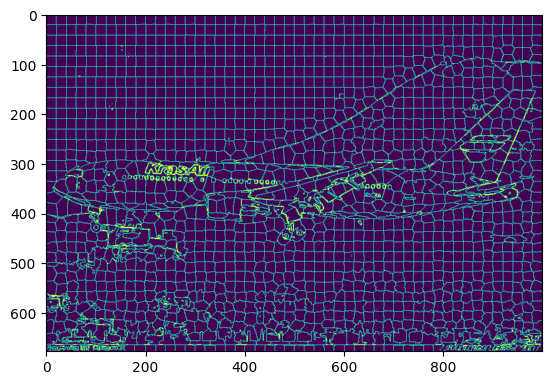

In [325]:
plt.imshow(mask)